In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

**Initialize Spark Session**

In [ ]:
spark = SparkSession.builder.appName("AirlineDelayAnalysis").getOrCreate()

**Load dataset**

In [ ]:
df = spark.read.csv("/content/Airline_Delay_Cause.csv", header=True, inferSchema=True)
df.show()
df.count()
df.printSchema()

+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

**Null checks**

In [ ]:
null_counts = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show()


+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|                657|
+----+-----+-------+

**Replace nulls with 0 for numerical columns** **(Imputations)**

In [ ]:
df = df.fillna(0)

**Filter out records where total flights are 0 to avoid division errors (Outlier rules)**

In [ ]:
df = df.filter((F.col("arr_flights") > 0))
df.show()
df.count()


+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

397576

**Flight delays over time**

In [ ]:
time_agg = df.groupBy("year", "month").agg(
    F.sum("arr_del15").alias("total_delays"),
    F.sum("arr_flights").alias("total_flights")
).withColumn("delay_rate", F.col("total_delays") / F.col("total_flights"))
time_agg.show()

+----+-----+------------+-------------+-------------------+
|year|month|total_delays|total_flights|         delay_rate|
+----+-----+------------+-------------+-------------------+
|2022|   10|       93056|       595322|0.15631204625396003|
|2024|    7|      191746|       676807| 0.2833097175413375|
|2015|    2|       95179|       429191|0.22176373689103454|
|2019|   10|      115688|       692944|0.16695144196356415|
|2017|    3|       88638|       488597|0.18141331199331964|
|2017|    8|      104709|       510451|0.20513036510850208|
|2014|    4|       91806|       483499|0.18987836582909168|
|2020|    6|       15945|       237264|0.06720362128262189|
|2019|    5|      137175|       694311|0.19756996504448296|
|2018|   10|      111921|       670117|0.16701710298350886|
|2017|   10|       69027|       479797|0.14386709379174942|
|2021|    8|      136036|       611494|0.22246497921484104|
|2016|    7|      113601|       502457|0.22609098888064053|
|2015|   12|       96772|       479230|0

**Convert to pandas for plotting**

In [ ]:
pd_time = time_agg.toPandas().sort_values(["year", "month"])
pd_time['date'] = pd.to_datetime(pd_time[['year', 'month']].assign(day=1))

**Airlines with highest percentage of delayed flights**

In [ ]:
carrier_agg = df.groupBy("carrier_name").agg(
    F.sum("arr_del15").alias("total_delays"),
    F.sum("arr_flights").alias("total_flights")
).withColumn("avg_delay_rate", F.col("total_delays") / F.col("total_flights")) \
 .orderBy(F.desc("avg_delay_rate"))

pd_carrier = carrier_agg.limit(10).toPandas()

**Airlines with most carrier-caused delays**

In [ ]:
carrier_caused_agg = df.groupBy("carrier_name").agg(
    F.sum("carrier_ct").alias("total_carrier_ct")
).orderBy(F.desc("total_carrier_ct"))

pd_carrier_caused = carrier_caused_agg.limit(10).toPandas()

**Airports with highest delay rates**

In [ ]:
airport_agg = df.groupBy("airport").agg(
    F.sum("arr_del15").alias("total_delays"),
    F.sum("arr_flights").alias("total_flights")
).withColumn("delay_rate", F.col("total_delays") / F.col("total_flights")) \
 .orderBy(F.desc("delay_rate"))

pd_airport = airport_agg.limit(10).toPandas()

**Dominant causes of delays across years (Stacked Bar)**

In [ ]:
causes = ["carrier_ct", "weather_ct", "nas_ct", "security_ct", "late_aircraft_ct"]
year_causes = df.groupBy("year").agg(*[F.sum(c).alias(c) for c in causes])
pd_year_causes = year_causes.toPandas().set_index('year').sort_index()
pd_year_causes_pct = pd_year_causes.div(pd_year_causes.sum(axis=1), axis=0) * 100

**Causes variation by season (Month)**

In [ ]:
month_causes = df.groupBy("month").agg(*[F.sum(c).alias(c) for c in causes]).orderBy("month")
pd_month_causes = month_causes.toPandas()

**Highest and lowest delay percentages by month**

In [ ]:
month_delay = df.groupBy("month").agg(
    F.sum("arr_del15").alias("total_delays"),
    F.sum("arr_flights").alias("total_flights")
).withColumn("delay_rate", F.col("total_delays") / F.col("total_flights")).orderBy("month")

pd_month_delay = month_delay.toPandas()

**1. Delays over time**

Text(0.5, 1.0, 'Flight Delay Rate Over Time')

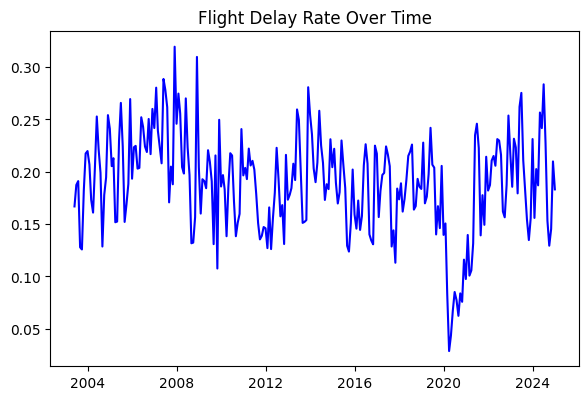

In [ ]:
plt.figure(figsize=(15, 20))
plt.subplot(4, 2, 1)
plt.plot(pd_time['date'], pd_time['delay_rate'], color='blue')
plt.title("Flight Delay Rate Over Time")

**2. Carrier delay rate**

Text(0.5, 1.0, 'Top 10 Airlines by Delay Rate')

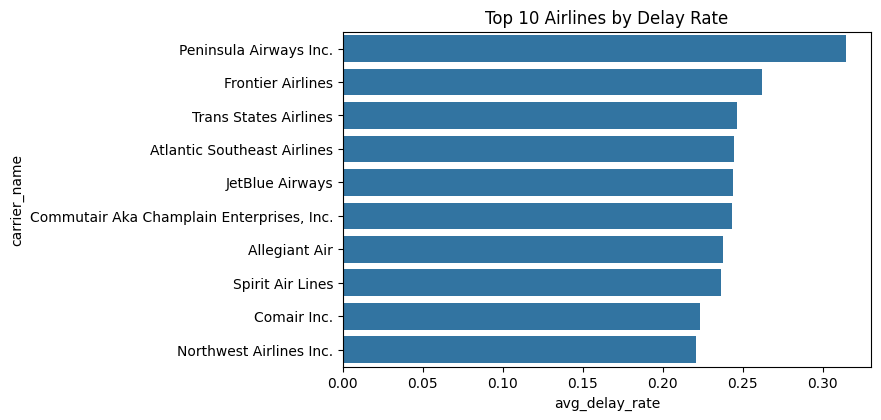

In [ ]:
plt.figure(figsize=(15, 20))
plt.subplot(4, 2, 2)
sns.barplot(data=pd_carrier, x='avg_delay_rate', y='carrier_name')
plt.title("Top 10 Airlines by Delay Rate")

**3. Carrier-caused counts**

Text(0.5, 1.0, 'Top 10 Airlines: Carrier-Caused Delay Counts')

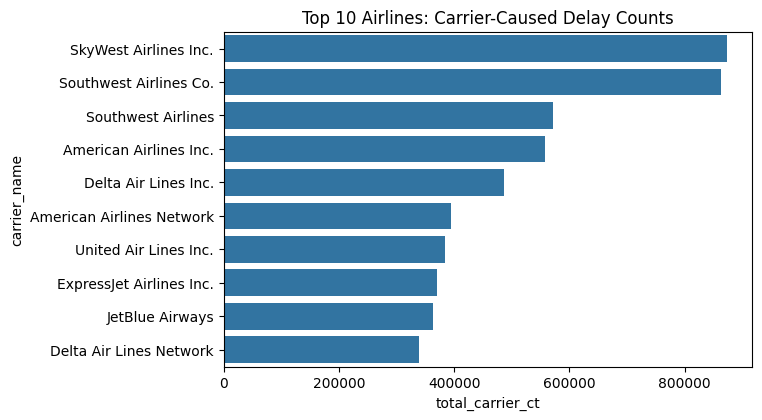

In [ ]:
plt.figure(figsize=(15, 20))
plt.subplot(4, 2, 3)
sns.barplot(data=pd_carrier_caused, x='total_carrier_ct', y='carrier_name')
plt.title("Top 10 Airlines: Carrier-Caused Delay Counts")

**4. Airport delay rate**

Text(0.5, 1.0, 'Top 10 Airports by Delay Rate')

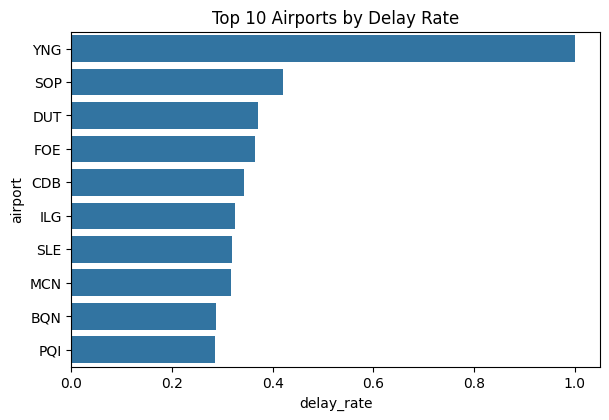

In [ ]:
plt.figure(figsize=(15, 20))
plt.subplot(4, 2, 4)
sns.barplot(data=pd_airport, x='delay_rate', y='airport')
plt.title("Top 10 Airports by Delay Rate")

**5. Causes distribution by year**

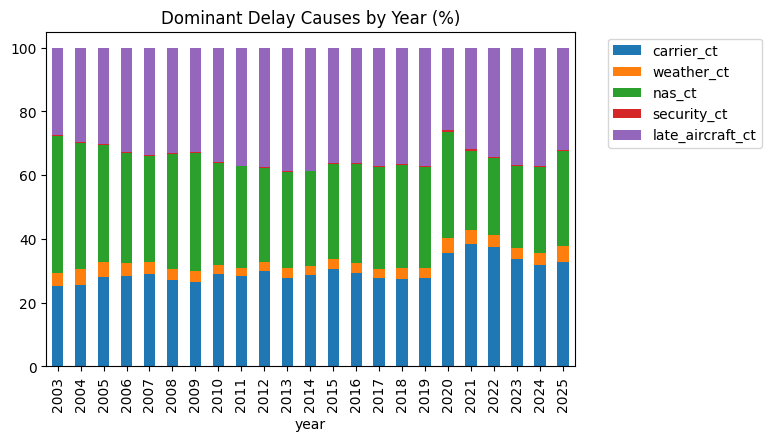

In [ ]:
plt.figure(figsize=(15, 20))
plt.subplot(4, 2, 5)
pd_year_causes_pct.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Dominant Delay Causes by Year (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

**6. Causes by season**

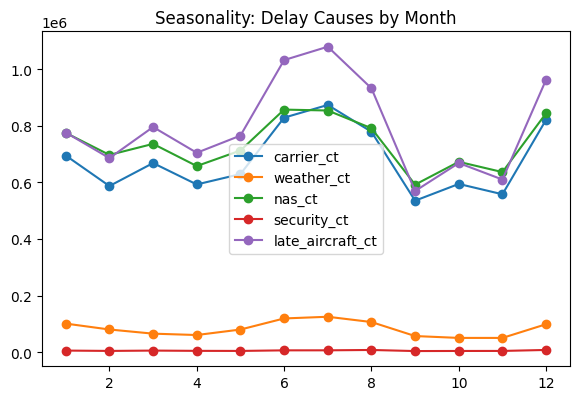

In [ ]:
plt.figure(figsize=(15, 20))
plt.subplot(4, 2, 6)
for cause in causes:
    plt.plot(pd_month_causes['month'], pd_month_causes[cause], label=cause, marker='o')
plt.title("Seasonality: Delay Causes by Month")
plt.legend()

**7. Delay percentage by month**

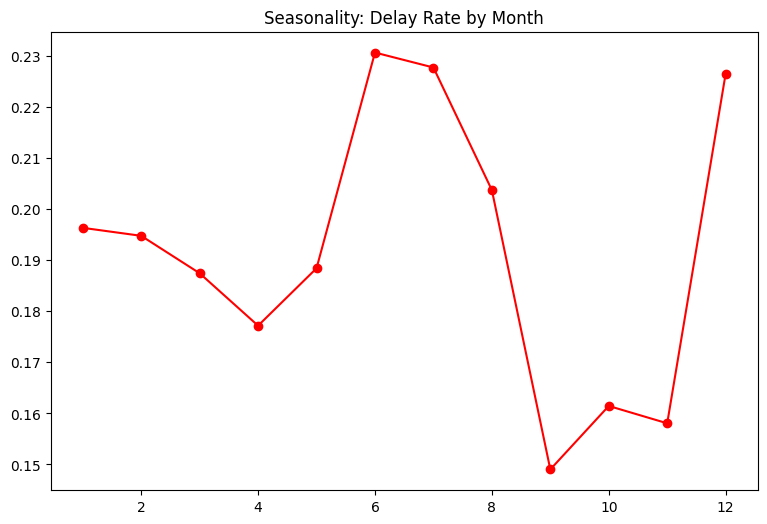

In [ ]:
plt.figure(figsize=(15, 20))
plt.subplot(4, 2, 7)
plt.plot(pd_month_delay['month'], pd_month_delay['delay_rate'], marker='o', color='red')
plt.title("Seasonality: Delay Rate by Month")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import _message
import json

content = _message.blocking_request('get_ipynb')['ipynb']

with open('Week2_25_SakshiHasurkar.ipynb', 'w') as f:
    json.dump(content, f)

In [ ]:
!pip install nbconvert
!jupyter nbconvert --to html Week2_25_SakshiHasurkar.ipynb

[NbConvertApp] Converting notebook Week2_25_SakshiHasurkar.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 667040 bytes to Week2_25_SakshiHasurkar.html


In [ ]:
from google.colab import files
files.download("Week2_25_SakshiHasurkar.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>